# CIE 555 - Assignment 2: Face Verification & Identification
## Siamese Networks with Custom CNN & Transfer Learning

**Objectives Met in this Notebook:**
1. **Data Engineering:** Programmatic parsing and filtering of the LFW dataset.
2. **Architecture Design:** Custom CNN and Transfer Learning (MobileNetV2) Siamese networks.
3. **Loss Implementation:** Manual implementation of Contrastive Loss and Triplet Loss.
4. **Evaluation:** Distance distribution plots, learning curves, and an inference pipeline.

### SECTION 1: Imports & Global Configuration

In [2]:
!pip install kagglehub -q

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

import kagglehub
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Dense, GlobalAveragePooling2D, Lambda,
    Concatenate, LeakyReLU, Layer
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Configured: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU Configured: True


In [3]:
# Download datasets via KaggleHub (Works perfectly in Google Colab)
print("Downloading LFW Dataset...")
lfw_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print(f"LFW Path: {lfw_path}")

# Configure paths
DATA_ROOT = Path(lfw_path) / "lfw-deepfunneled" / "lfw-deepfunneled"
if not DATA_ROOT.exists():
    DATA_ROOT = Path(lfw_path) / "lfw-deepfunneled"

OUTPUT_DIR = Path("processed_data")
MODELS_DIR = Path("saved_models")

OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
MODELS_DIR.mkdir(exist_ok=True, parents=True)

# ── Hyperparameters ────────────────────────────────────────────────────────────
MIN_IMAGES          = 5      # FIX: was 3 — persons with <5 imgs give <10 pairs; too sparse
MAX_IMAGES          = 50
IMG_SIZE            = (160, 160)   # 160×160 — optimal for LFW Siamese networks -> was 224 before but resulted in OOM 
IMG_SHAPE           = (IMG_SIZE[0], IMG_SIZE[1], 3)

TRAIN_SPLIT         = 0.70
VAL_SPLIT           = 0.20  # FIX: 15% -> 20% — larger val set = more stable val loss, before it was terrible
TEST_SPLIT          = 0.10  

PAIRS_PER_PERSON    = 40    # FIX: was 20 — doubled for richer training signal
TRIPLETS_PER_PERSON = 40    # FIX: was 20 — doubled for more diverse triplet coverage

BATCH_SIZE          = 64    # FIX: 32 -> 64 — larger batches = smoother gradient estimates = less val fluctuation
EPOCHS              = 40
LR                  = 1e-3
CONTRASTIVE_MARGIN  = 1.0
TRIPLET_MARGIN      = 0.5   # FIX: was 0.4 — stronger margin on L2-normed embeddings
EMBEDDING_DIM       = 128
RANDOM_SEED         = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"\n Configuration ready")

LFW Path: /kaggle/input/datasets/jessicali9530/lfw-dataset

 Configuration ready


### SECTION 2: Data Handling & Programmatic Filtering
We parse the raw folder structure and apply a filtering logic. Persons with too few images (<3) are dropped because they cannot form adequate triplets/pairs. Persons with too many (>50) are capped to prevent the network from biasing towards heavily represented identities.

In [4]:
# Parse raw dataset folder
person_image_counts = {}
if DATA_ROOT.exists():
    for person_folder in DATA_ROOT.iterdir():
        if person_folder.is_dir():
            images = list(person_folder.glob("*.jpg"))
            person_image_counts[person_folder.name] = len(images)
else:
    print(f"WARNING: Data root {DATA_ROOT} not found! Please check your dataset path.")

# Filter logical candidates
eligible_persons = {
    person: count
    for person, count in person_image_counts.items()
    if MIN_IMAGES <= count <= MAX_IMAGES
}

filtered_names = list(eligible_persons.keys())
print(f"Raw dataset identities: {len(person_image_counts)}")
print(f"Eligible identities after filtering ({MIN_IMAGES}-{MAX_IMAGES} imgs): {len(filtered_names)}")

Raw dataset identities: 5749
Eligible identities after filtering (5-50 imgs): 411


### EDA 1: Data Distribution Visualizations

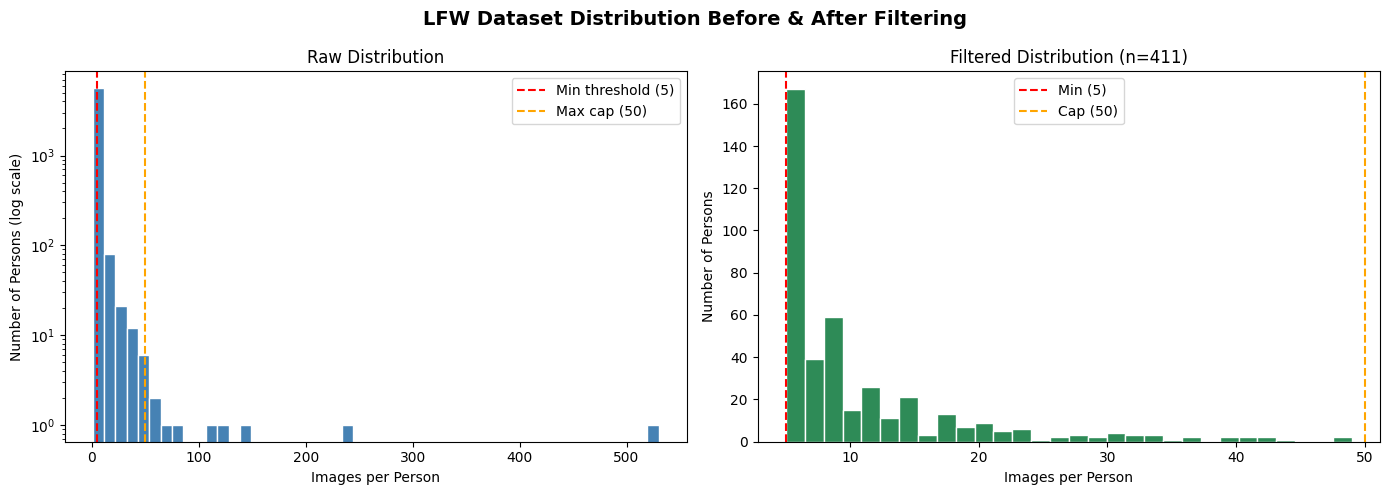

In [5]:
counts = list(person_image_counts.values())
filtered_counts = list(eligible_persons.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LFW Dataset Distribution Before & After Filtering", fontsize=14, fontweight='bold')

axes[0].hist(counts, bins=50, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel("Images per Person")
axes[0].set_ylabel("Number of Persons (log scale)")
axes[0].set_title("Raw Distribution")
axes[0].axvline(MIN_IMAGES, color='red', linestyle='--', label=f'Min threshold ({MIN_IMAGES})')
axes[0].axvline(MAX_IMAGES, color='orange', linestyle='--', label=f'Max cap ({MAX_IMAGES})')
axes[0].legend()

axes[1].hist(filtered_counts, bins=30, color='seagreen', edgecolor='white')
axes[1].set_xlabel("Images per Person")
axes[1].set_ylabel("Number of Persons")
axes[1].set_title(f"Filtered Distribution (n={len(eligible_persons)})")
axes[1].axvline(MIN_IMAGES, color='red', linestyle='--', label=f'Min ({MIN_IMAGES})')
axes[1].axvline(MAX_IMAGES, color='orange', linestyle='--', label=f'Cap ({MAX_IMAGES})')
axes[1].legend()

plt.tight_layout()
plt.show()

### SECTION 3: Open-Set Split & CSV Generation
We split the dataset at the **identity (person) level** using the 70/20/10 protocol.

In [6]:
# Split persons into Train (70%), Val (20%), Test (10%) -> The logical choice for this problem
train_persons, temp_persons = train_test_split(
    filtered_names,
    test_size=(VAL_SPLIT + TEST_SPLIT),
    random_state=RANDOM_SEED #-> reproducability
)
val_persons, test_persons = train_test_split(
    temp_persons,
    test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    random_state=RANDOM_SEED
)

print(f"Splits -> Train: {len(train_persons)} | Val: {len(val_persons)} | Test: {len(test_persons)}")

PERSON_PATHS_CACHE = {}
for person in filtered_names:
    PERSON_PATHS_CACHE[person] = sorted([str(p) for p in (DATA_ROOT / person).glob("*.jpg")])

def generate_pairs_df(persons, pairs_per_person):
    rows = []
    for person in persons:
        paths = PERSON_PATHS_CACHE[person]
        if len(paths) < 2: continue

        # Positive pairs
        pos_count = 0
        for i in range(len(paths)):
            for j in range(i + 1, len(paths)):
                if pos_count >= pairs_per_person: break
                rows.append({'path1': paths[i], 'path2': paths[j], 'label': 1})
                pos_count += 1

        # Diverse negatives — rotate through shuffled other persons -> get the other than the person -> shuffle them ->
        # -> select the negative pair then assign thier label to "0" -> negative pair
        other_persons = [p for p in persons if p != person]
        random.shuffle(other_persons)
        for idx in range(pos_count):
            neg_person = other_persons[idx % len(other_persons)]  # cycle through all identities
            neg_paths  = PERSON_PATHS_CACHE[neg_person]
            rows.append({'path1': random.choice(paths), 'path2': random.choice(neg_paths), 'label': 0})

    return pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

def generate_triplets_df(persons, triplets_per_person): # the Hard mining
    # DATA ENGINEERING FIX from a failed previous run — Diverse Negatives + Anchor Variety
    # Previous version picked one random negative person per triplet.
    # cycle through shuffled other_persons so each triplet's negative identity is different, 
    # preventing the model from fixating on a small set of easy negative identities.
    # this notes are reminders of my progress in this notebook in case I will enhance it more IsA
    rows = []
    for person in persons:
        paths = PERSON_PATHS_CACHE[person]
        if len(paths) < 2: continue

        other_persons = [p for p in persons if p != person]
        random.shuffle(other_persons)
        count = 0
        for i in range(len(paths)):
            for j in range(i + 1, len(paths)):
                if count >= triplets_per_person: break
                # FIX: cycle through all other identities for diverse negatives
                neg_person = other_persons[count % len(other_persons)]
                neg_paths  = PERSON_PATHS_CACHE[neg_person]
                rows.append({
                    'anchor':   paths[i],
                    'positive': paths[j],
                    'negative': random.choice(neg_paths)
                })
                count += 1
    return pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Generate DataFrames
df_pairs_train = generate_pairs_df(train_persons, PAIRS_PER_PERSON)
df_pairs_val = generate_pairs_df(val_persons, PAIRS_PER_PERSON)
df_pairs_test = generate_pairs_df(test_persons, PAIRS_PER_PERSON)

df_triplets_train = generate_triplets_df(train_persons, TRIPLETS_PER_PERSON)
df_triplets_val = generate_triplets_df(val_persons, TRIPLETS_PER_PERSON)
df_triplets_test = generate_triplets_df(test_persons, TRIPLETS_PER_PERSON)

print(f"Train Pairs: {len(df_pairs_train)} | Val Pairs: {len(df_pairs_val)}")
print(f"Train Triplets: {len(df_triplets_train)} | Val Triplets: {len(df_triplets_val)}")

Splits -> Train: 287 | Val: 82 | Test: 42
Train Pairs: 14796 | Val Pairs: 4232
Train Triplets: 7398 | Val Triplets: 2116


In [34]:
# Data Engineering Quality Check
# 1. Are we generating enough pairs per person?
# 2. Is the positive/negative balance correct?
# 3. Are negatives diverse (not all from the same identity)?

# Pair count stats
pos_count = (df_pairs_train['label'] == 1).sum()
neg_count = (df_pairs_train['label'] == 0).sum()
print(f"\nTrain Pairs  : {len(df_pairs_train):,} total  |  Pos: {pos_count:,}  Neg: {neg_count:,}")
print(f"Balance ratio: {neg_count/pos_count:.2f}x (ideal ≈ 1.0)")

# Pairs per person histogram
pair_counts_per_person = (
    pd.concat([df_pairs_train[['path1','label']].rename(columns={'path1':'path'}),
               df_pairs_train[['path2','label']].rename(columns={'path2':'path'})])
    .groupby('path').size()
)
print(f"\nPositive pairs — avg per image: {pos_count/len(df_pairs_train['path1'].unique()):.1f}")

# Negative diversity check — unique neg identities per person
neg_diversity = df_pairs_train[df_pairs_train['label']==0].groupby('path1')['path2'].apply(
    lambda x: x.apply(lambda p: Path(p).parent.name).nunique()
).describe()
print(f"\nNeg identity diversity per anchor:")
print(f"Mean unique neg persons : {neg_diversity['mean']:.1f}")
print(f"Min unique neg persons  : {neg_diversity['min']:.0f}")

# Triplet stats
print(f"\nTrain Triplets: {len(df_triplets_train):,}")
print(f"Val Triplets    : {len(df_triplets_val):,}")
print(f"Test Triplets   : {len(df_triplets_test):,}")

# Image count distribution for training persons
train_img_counts = [len(PERSON_PATHS_CACHE[p]) for p in train_persons]
print(f"\nTraining persons: {len(train_persons)} identities")
print(f"  Avg images/person : {np.mean(train_img_counts):.1f}")
print(f"  Min images/person : {np.min(train_img_counts)}")
print(f"  Max images/person : {np.max(train_img_counts)}")


Train Pairs  : 14,796 total  |  Pos: 7,398  Neg: 7,398
Balance ratio: 1.00x (ideal ≈ 1.0)

Positive pairs — avg per image: 2.6

Neg identity diversity per anchor:
Mean unique neg persons : 2.7
Min unique neg persons  : 1

Train Triplets: 7,398
Val Triplets    : 2,116
Test Triplets   : 950

Training persons: 287 identities
  Avg images/person : 10.8
  Min images/person : 5
  Max images/person : 49


### EDA 2: Split Distribution & Dataset Samples

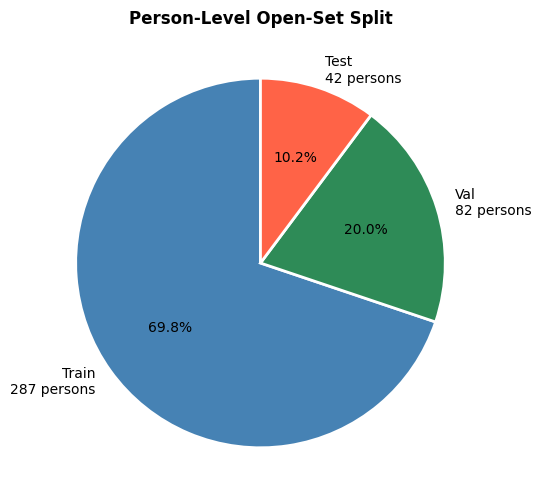

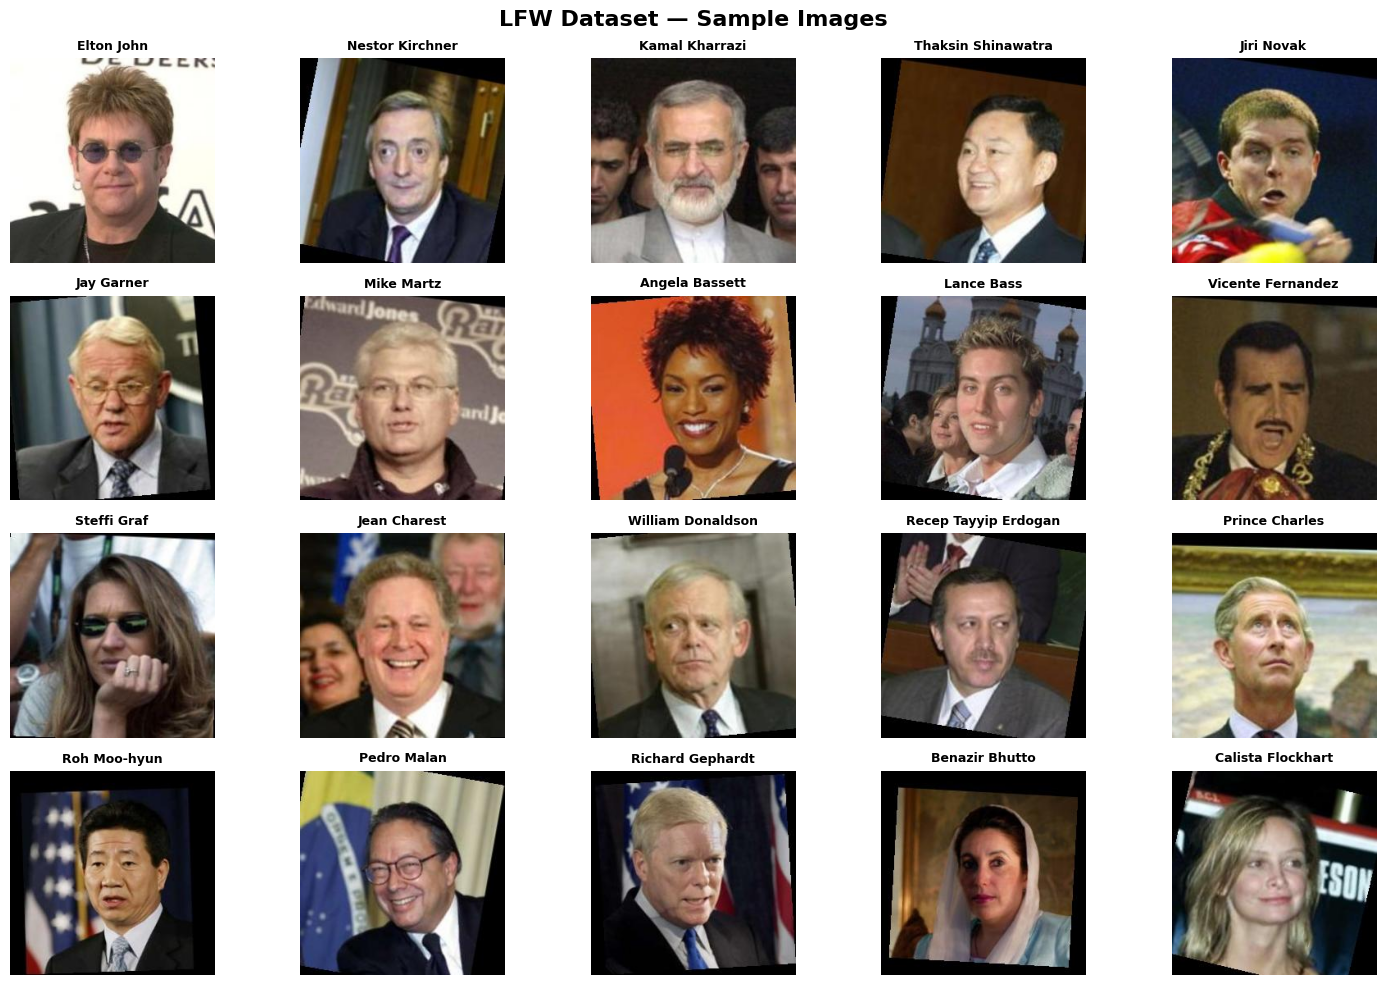

In [8]:
# 1. Split Pie Chart
split_labels = [f'Train\n{len(train_persons)} persons', f'Val\n{len(val_persons)} persons', f'Test\n{len(test_persons)} persons']
split_sizes = [len(train_persons), len(val_persons), len(test_persons)]
colors = ['steelblue', 'seagreen', 'tomato']

plt.figure(figsize=(6, 6))
plt.pie(split_sizes, labels=split_labels, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title("Person-Level Open-Set Split", fontweight='bold')
plt.show()

# 2. Sample 20 Images from Dataset
sample_persons = random.sample(filtered_names, min(20, len(filtered_names)))
fig, axes = plt.subplots(4, 5, figsize=(15, 10))
fig.suptitle('LFW Dataset — Sample Images', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, person in enumerate(sample_persons):
    paths = PERSON_PATHS_CACHE[person]
    if len(paths) > 0:
        img = mpimg.imread(random.choice(paths))
        axes[idx].imshow(img)
        axes[idx].set_title(person.replace('_', ' '), fontsize=9, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

### EDA 3: Pair & Triplet Visualizations

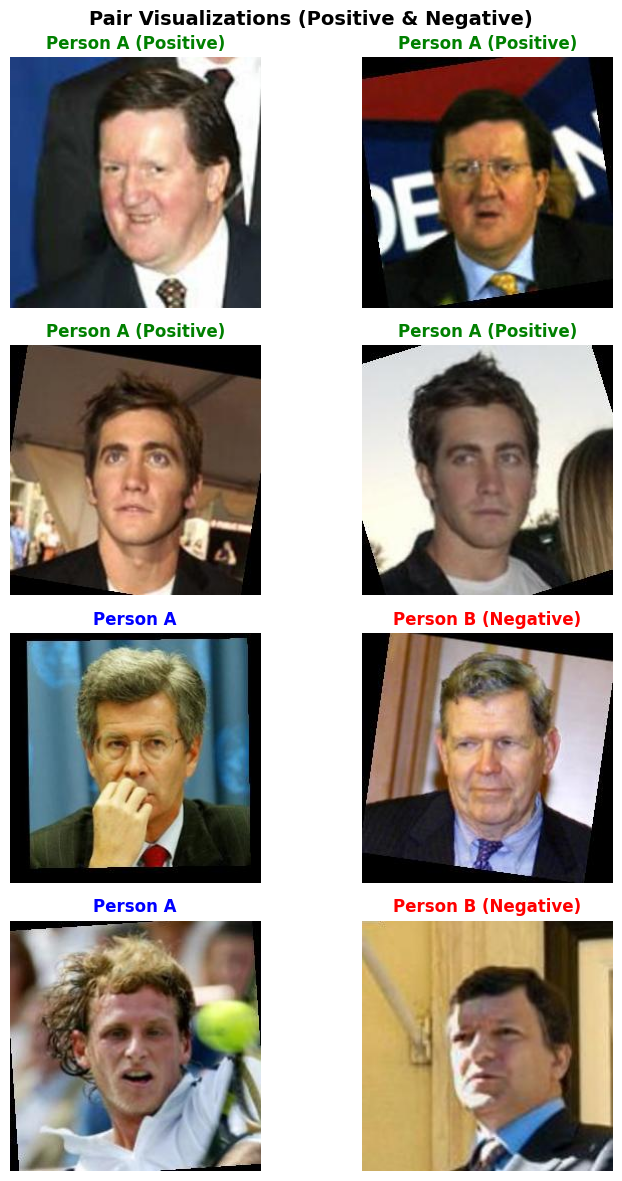

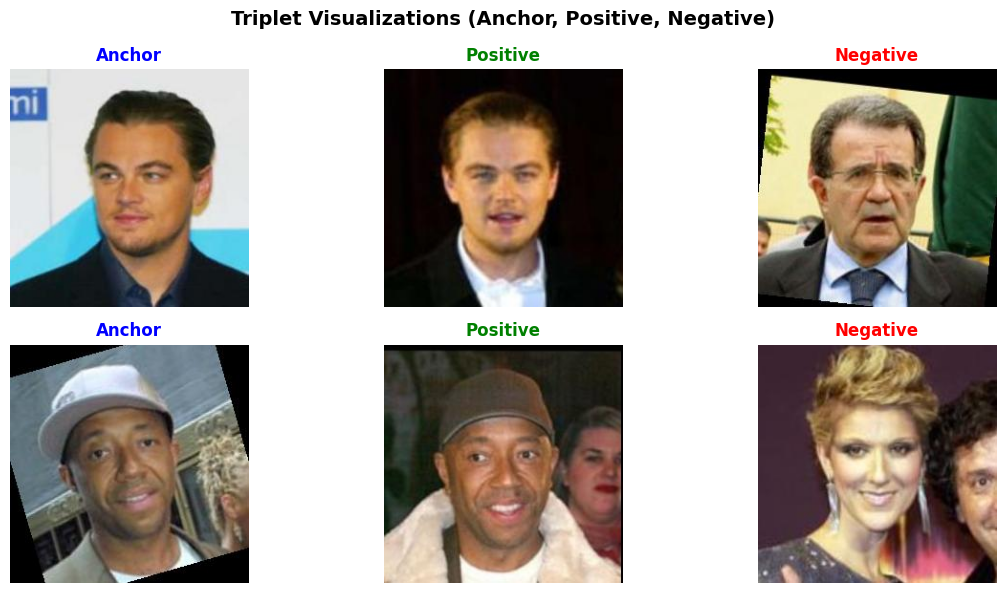

In [9]:
def plot_pairs(df, num_samples=2):
    pos_pairs = df[df['label'] == 1].sample(num_samples, random_state=RANDOM_SEED)
    neg_pairs = df[df['label'] == 0].sample(num_samples, random_state=RANDOM_SEED)

    fig, axes = plt.subplots(num_samples * 2, 2, figsize=(8, 3 * num_samples * 2))
    fig.suptitle("Pair Visualizations (Positive & Negative)", fontsize=14, fontweight='bold')

    for i, (_, row) in enumerate(pos_pairs.iterrows()):
        axes[i, 0].imshow(mpimg.imread(row['path1']))
        axes[i, 0].set_title("Person A (Positive)", color='green', fontweight='bold')
        axes[i, 0].axis('off')
        axes[i, 1].imshow(mpimg.imread(row['path2']))
        axes[i, 1].set_title("Person A (Positive)", color='green', fontweight='bold')
        axes[i, 1].axis('off')

    for i, (_, row) in enumerate(neg_pairs.iterrows()):
        idx = i + num_samples
        axes[idx, 0].imshow(mpimg.imread(row['path1']))
        axes[idx, 0].set_title("Person A", color='blue', fontweight='bold')
        axes[idx, 0].axis('off')
        axes[idx, 1].imshow(mpimg.imread(row['path2']))
        axes[idx, 1].set_title("Person B (Negative)", color='red', fontweight='bold')
        axes[idx, 1].axis('off')
    plt.tight_layout()
    plt.show()

def plot_triplets(df, num_samples=3):
    samples = df.sample(num_samples, random_state=RANDOM_SEED)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3 * num_samples))
    fig.suptitle("Triplet Visualizations (Anchor, Positive, Negative)", fontsize=14, fontweight='bold')

    for i, (_, row) in enumerate(samples.iterrows()):
        axes[i, 0].imshow(mpimg.imread(row['anchor']))
        axes[i, 0].set_title("Anchor", color='blue', fontweight='bold')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mpimg.imread(row['positive']))
        axes[i, 1].set_title("Positive", color='green', fontweight='bold')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(mpimg.imread(row['negative']))
        axes[i, 2].set_title("Negative", color='red', fontweight='bold')
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.show()

plot_pairs(df_pairs_train, num_samples=2)
plot_triplets(df_triplets_train, num_samples=2)

### SECTION 4: Image Pipelines & Augmentation

In [10]:
def load_image(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0, 1]
    return img

@tf.function
def augment(img):
    """
    PREPROCESSING FIX — Face-appropriate augmentation:
    KEPT:    flip (faces are symmetric), brightness/contrast (lighting changes).
    ADDED:   random_crop + resize — simulates head pose & zoom variation,
             the single most useful augmentation for face datasets.
             Mild Gaussian noise for regularization.
    """
    # Geometric (most valuable for faces)
    img_h, img_w = IMG_SIZE[0], IMG_SIZE[1]
    crop_frac = tf.random.uniform([], 0.85, 1.0)
    crop_h = tf.cast(tf.cast(img_h, tf.float32) * crop_frac, tf.int32)
    crop_w = tf.cast(tf.cast(img_w, tf.float32) * crop_frac, tf.int32)
    crop_size = tf.stack([crop_h, crop_w, 3])
    img = tf.image.random_crop(img, size=crop_size)
    img = tf.image.resize(img, [img_h, img_w]) # resize back to IMG_SIZE

    # Photometric (lighting variation only — NO colour shift)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)

    # Noise
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.008, dtype=tf.float32)
    img = img + noise

    return tf.clip_by_value(img, 0.0, 1.0)

# tf.data pipeline builders
def parse_pair(p1, p2, label, training):
    img1, img2 = load_image(p1), load_image(p2)
    if training: # the online augmentation -> aug them on the run
        img1, img2 = augment(img1), augment(img2) 
    return (img1, img2), tf.cast(label, tf.float32)

def parse_triplet(a, p, n, training):
    anchor, pos, neg = load_image(a), load_image(p), load_image(n)
    if training:
        anchor, pos, neg = augment(anchor), augment(pos), augment(neg)
    return (anchor, pos, neg), tf.constant(0.0) # Dummy label for triplet

def build_dataset(df, task='pair', training=True):
    if task == 'pair':
        ds = tf.data.Dataset.from_tensor_slices((df['path1'].values, df['path2'].values, df['label'].values))
        ds = ds.map(lambda p1, p2, lbl: parse_pair(p1, p2, lbl, training), num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = tf.data.Dataset.from_tensor_slices((df['anchor'].values, df['positive'].values, df['negative'].values))
        ds = ds.map(lambda a, p, n: parse_triplet(a, p, n, training), num_parallel_calls=tf.data.AUTOTUNE)

    if training: ds = ds.shuffle(4096)  #1024 -> 4096 — was only shuffling 4% of dataset
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ds_pairs_train = build_dataset(df_pairs_train, 'pair', True)
ds_pairs_val = build_dataset(df_pairs_val, 'pair', False)
ds_pairs_test = build_dataset(df_pairs_test, 'pair', False)

ds_triplets_train = build_dataset(df_triplets_train, 'triplet', True)
ds_triplets_val = build_dataset(df_triplets_val, 'triplet', False)
ds_triplets_test = build_dataset(df_triplets_test, 'triplet', False)

### EDA 4: Online Augmentation Demo

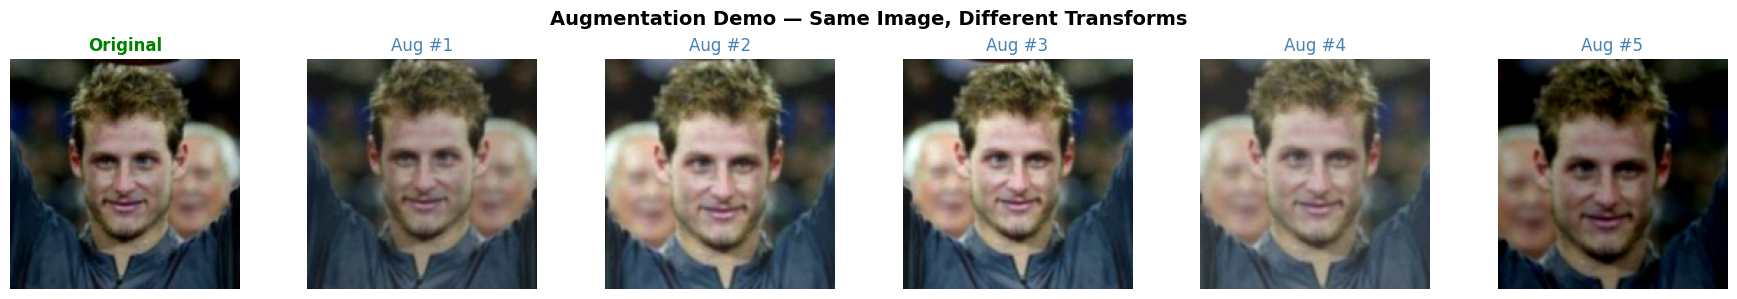

In [11]:
sample_path = df_pairs_train["path1"].iloc[0]
original = load_image(sample_path).numpy()

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
fig.suptitle("Augmentation Demo — Same Image, Different Transforms", fontsize=14, fontweight="bold")

axes[0].imshow(original)
axes[0].set_title("Original", color="green", fontweight='bold')
axes[0].axis("off")

for i in range(1, 6):
    aug_img = augment(tf.constant(original)).numpy()
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Aug #{i}", color="steelblue")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### SECTION 5: Loss Functions & Accuracy Metrics (Manual Implementation)
Both loss functions are implemented **from scratch** as required by the assignment.

**Contrastive Loss:** `L = y·d² + (1-y)·max(margin - d, 0)²`
- `y=1` → same person → minimize distance `d`
- `y=0` → different person → push distance beyond margin

**Triplet Loss:** `L = max(d(a,p) - d(a,n) + margin, 0)`
- Forces: distance(anchor, negative) > distance(anchor, positive) + margin

In [12]:
def get_contrastive_loss(margin=1.0):
    def contrastive_loss(y_true, y_pred):
        # y_true=1 -> same person (positive pair) -> minimize distance
        # y_true=0 -> different person (negative pair) -> push beyond margin
        y_true  = tf.cast(y_true, tf.float32)
        pos_loss = y_true * tf.square(y_pred)
        neg_loss = (1.0-y_true) * tf.square(tf.maximum(margin - y_pred, 0.0))
        return tf.reduce_mean(pos_loss + neg_loss)
    return contrastive_loss


def get_triplet_loss(margin=0.5):
    def triplet_loss(y_true, y_pred):
        # y_pred shape: (batch, 3 * EMBEDDING_DIM) — anchor|positive|negative concatenated

        anchor   = y_pred[:, :EMBEDDING_DIM]
        positive = y_pred[:, EMBEDDING_DIM:2*EMBEDDING_DIM]
        negative = y_pred[:, 2*EMBEDDING_DIM:]
        # FIXED: true Euclidean distance (not squared)
        d_pos = tf.norm(anchor - positive, axis=1)
        d_neg = tf.norm(anchor - negative, axis=1)
        return tf.reduce_mean(tf.maximum(d_pos - d_neg + margin, 0.0))
    return triplet_loss


def contrastive_accuracy(y_true, y_pred):
    threshold   = 0.7
    predictions = tf.cast(y_pred < threshold, tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, predictions), tf.float32))


def triplet_accuracy(y_true, y_pred):
    #Checks if positive pair is closer than negative pair (Euclidean distance).
    anchor   = y_pred[:, :EMBEDDING_DIM]
    positive = y_pred[:, EMBEDDING_DIM:2*EMBEDDING_DIM]
    negative = y_pred[:, 2*EMBEDDING_DIM:]
    d_pos = tf.norm(anchor - positive, axis=1)   # FIXED: true Euclidean
    d_neg = tf.norm(anchor - negative, axis=1)   # FIXED: true Euclidean
    return tf.reduce_mean(tf.cast(d_pos < d_neg, tf.float32))

print(" Loss functions and metrics defined")


 Loss functions and metrics defined


### SECTION 6: Model Architectures

**Design Decisions — Custom CNN:**
- **4 blocks** (32 -> 64 -> 128 -> 256 filters): progressive feature hierarchy from edges to identity-level representations.
- **BatchNormalization after each block**: stabilizes activations across the 4-block depth and reduces internal covariate shift.
- **Pattern B** (two 3×3 convs per block): equivalent receptive field to 5×5 with extra non-linearity.
- **LeakyReLU (α=0.1)**: prevents dying neurons in embedding space.
- **GAP** instead of Flatten: 16K vs 800K parameters — critical for small datasets.
- **Dropout** for regularization (no BN).
- **L2 Normalization** via custom layer (not Lambda): bounds distances to [0,2], prevents magnitude exploits.

**Design Decisions — Transfer Learning (EfficientNetB0):**
- Replaces MobileNetV2: EfficientNetB0 has ~5.3M params vs MobileNetV2's ~3.4M, with significantly stronger ImageNet features due to compound scaling.
- EfficientNet's compound scaling optimizes depth, width, and resolution together — better feature hierarchy for subtle face differences.
- Takes raw [0,255] input; internal rescaling layer handles normalization — no manual preprocessing error possible.
- Two-phase training: frozen base (head warm-up) → selective fine-tune of top layers at low LR.

In [13]:
class L2NormalizeLayer(Layer):
    """
    Projects embeddings onto the unit hypersphere via L2 normalization.
    Ensures distances are bounded in [0, 2] and margin is consistent.
    """
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)

    def get_config(self):
        return super().get_config()


class EuclideanDistanceLayer(Layer):

    def call(self, inputs):
        emb_a, emb_b = inputs
        squared_diff = tf.reduce_sum(tf.square(emb_a - emb_b), axis=1)  # shape: (batch,)
        return tf.sqrt(tf.maximum(squared_diff, K.epsilon()))  # shape: (batch,)

    def get_config(self):
        return super().get_config()

class EfficientNetPreprocessLayer(Layer):
    
    def call(self, inputs):
        # inputs are [0,1] from load_image; scale to [0,255] first
        x = inputs * 255.0
        # efficientnet_preprocess maps [0,255] -> [-1,1]
        return efficientnet_preprocess(x)

    def get_config(self):
        return super().get_config()

print("Custom layers defined")

Custom layers defined


In [14]:
def build_cnn_backbone(input_shape=IMG_SHAPE, emb_dim=EMBEDDING_DIM):

    inputs = Input(shape=input_shape, name="cnn_input")

    #  Block 1: Low-level features (edges, textures)
    x = Conv2D(32, (3,3), padding="same", name="conv1_1")(inputs)
    x = LeakyReLU(alpha=0.1, name="lrelu1_1")(x)
    x = Conv2D(32, (3,3), padding="same", name="conv1_2")(x)
    x = LeakyReLU(alpha=0.1, name="lrelu1_2")(x)
    # Add BN
    x = BatchNormalization(name="bn1")(x)
    x = MaxPooling2D((2,2), name="pool1")(x)
    x = Dropout(0.10, name="drop1")(x)

    #  Block 2: Mid-level shapes 
    x = Conv2D(64, (3,3), padding="same", name="conv2_1")(x)
    x = LeakyReLU(alpha=0.1, name="lrelu2_1")(x)
    x = Conv2D(64, (3,3), padding="same", name="conv2_2")(x)
    x = LeakyReLU(alpha=0.1, name="lrelu2_2")(x)
    # Add BN
    x = BatchNormalization(name="bn2")(x)
    x = MaxPooling2D((2,2), name="pool2")(x)
    x = Dropout(0.15, name="drop2")(x)

    #  Block 3: High-level identity features 
    x = Conv2D(128, (3,3), padding="same", name="conv3_1")(x)
    x = LeakyReLU(alpha=0.1, name="lrelu3_1")(x)
    x = Conv2D(128, (3,3), padding="same", name="conv3_2")(x)
    x = LeakyReLU(alpha=0.1, name="lrelu3_2")(x)
    # Add BN
    x = BatchNormalization(name="bn3")(x)
    x = MaxPooling2D((2,2), name="pool3")(x)
    x = Dropout(0.15, name="drop3")(x)

    #  Block 4: High-level identity features (deep representation)
    x = Conv2D(256, (3,3), padding="same", name="conv4_1")(x)
    x = LeakyReLU(alpha=0.1, name="lrelu4_1")(x)
    x = Conv2D(256, (3,3), padding="same", name="conv4_2")(x)
    x = LeakyReLU(alpha=0.1, name="lrelu4_2")(x)

    x = BatchNormalization(name="bn4")(x)
    x = Dropout(0.20, name="drop4")(x)  # consistent with other blocks
    x = GlobalAveragePooling2D(name="gap")(x)


    #  Embedding head 
    x   = Dense(emb_dim, activation="relu", name="emb_dense1")(x)
    x   = Dropout(0.20, name="emb_drop")(x)
    x   = Dense(emb_dim, activation=None, name="emb_dense2")(x)
    # FIX: L2NormalizeLayer replaces Lambda — fully serializable in Keras 3 -> in kaggle env
    out = L2NormalizeLayer(name="l2_norm")(x)

    model = Model(inputs, out, name="CNN_Backbone")
    return model

backbone_test = build_cnn_backbone()
backbone_test.summary()
total = sum(p.numpy().size for p in backbone_test.trainable_weights)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "CNN_Backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_input (InputLayer)          │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu1_1 (LeakyReLU)            │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu1_2 (LeakyReLU)            │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 160, 160, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu2_1 (LeakyReLU)            │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu2_2 (LeakyReLU)            │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 80, 80, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu3_1 (LeakyReLU)            │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu3_2 (LeakyReLU)            │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 40, 40, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu4_1 (LeakyReLU)            │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_2 (Conv2D)                │ (None, 20, 20, 256)    │       590,08

 Total params: 1,223,584 (4.67 MB)

 Trainable params: 1,222,624 (4.66 MB)

 Non-trainable params: 960 (3.75 KB)

In [15]:
def build_efficientnet_backbone(input_shape=IMG_SHAPE, emb_dim=EMBEDDING_DIM):

    base = EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
        pooling="avg",
    )
    base.trainable = False   # Phase 1: freeze entire base

    inputs = Input(shape=input_shape, name="efficientnet_input")

    x   = EfficientNetPreprocessLayer(name="efficientnet_preprocess")(inputs)
    x   = base(x, training=False)

    x   = Dense(256, activation="relu", name="emb_dense1")(x)
    x   = Dropout(0.35, name="emb_drop1")(x)
    x   = Dense(emb_dim, activation=None, name="emb_proj")(x)
    out = L2NormalizeLayer(name="l2_norm")(x)

    model = Model(inputs, out, name="EfficientNetB0_Backbone")
    return model, base

eff_test, _ = build_efficientnet_backbone()
eff_test.summary()
total = sum(p.numpy().size for p in eff_test.trainable_weights)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "EfficientNetB0_Backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnet_input (InputLayer) │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_preprocess         │ (None, 160, 160, 3)    │             0 │
│ (EfficientNetPreprocessLayer)   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emb_dense1 (Dense)              │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emb_drop1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emb_proj (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_norm (L2NormalizeLayer)      │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,403 (16.82 MB)

 Trainable params: 360,832 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
# ── FIX: Replace Lambda layers with custom EuclideanDistanceLayer ─────────────

def build_siamese_contrastive(backbone):
    """
    Siamese network for contrastive loss.
    Output: scalar Euclidean distance between the two embeddings.
    Uses EuclideanDistanceLayer instead of Lambda — safe for model saving.
    """
    img_a = Input(shape=IMG_SHAPE, name="img_a")
    img_b = Input(shape=IMG_SHAPE, name="img_b")
    emb_a = backbone(img_a)
    emb_b = backbone(img_b)
    # FIX: EuclideanDistanceLayer replaces Lambda([emb_a, emb_b])
    dist  = EuclideanDistanceLayer(name="euclidean_dist")([emb_a, emb_b])
    return Model([img_a, img_b], dist, name=f"Siamese_Contrastive_{backbone.name}")


def build_siamese_triplet(backbone):
    """
    Siamese network for triplet loss.
    Output: anchor|positive|negative embeddings concatenated along axis=-1.
    """
    anchor = Input(shape=IMG_SHAPE, name="anchor")
    positive = Input(shape=IMG_SHAPE, name="positive")
    negative = Input(shape=IMG_SHAPE, name="negative")
    emb_a = backbone(anchor)
    emb_p = backbone(positive)
    emb_n = backbone(negative)
    out = Concatenate(axis=-1, name="triplet_concat")([emb_a, emb_p, emb_n])
    return Model([anchor, positive, negative], out,name=f"Siamese_Triplet_{backbone.name}")

### SECTION 7: Training

In [17]:
def plot_training_history(history, title_prefix):
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{title_prefix} — Training Curves", fontsize=14, fontweight="bold")

    # Loss subplot
    axes[0].plot(history.history["loss"], label="Train Loss", color="steelblue",
                 linewidth=1.2, linestyle="--", alpha=0.7)
    axes[0].plot(history.history["val_loss"], label="Val Loss (key metric)", color="tomato", linewidth=2.8)

    best_epoch = int(np.argmin(history.history["val_loss"]))
    best_val  = min(history.history["val_loss"])
    axes[0].axvline(best_epoch, color="tomato", linestyle=":", alpha=0.6,
                    label=f"Best epoch: {best_epoch+1}")
    axes[0].scatter(best_epoch, best_val, color="tomato", s=80, zorder=5)
    axes[0].annotate(f"  Best val: {best_val:.4f}",
                     xy=(best_epoch, best_val), fontsize=9, color="tomato")
    axes[0].set_title(f"{title_prefix} — Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    #  Accuracy/metric subplot
    acc_keys = [k for k in history.history if "accuracy" in k and "val" not in k]
    if acc_keys:
        acc_key = acc_keys[0]
        val_acc_key = f"val_{acc_key}"
        axes[1].plot(history.history[acc_key],label="Train Accuracy",
                     color="steelblue", linewidth=1.2, linestyle="--", alpha=0.7)
        axes[1].plot(history.history[val_acc_key], label="Val Accuracy (key metric)",
                     color="seagreen", linewidth=2.8)
        axes[1].set_title(f"{title_prefix} — Accuracy", fontweight="bold")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "No accuracy metric recorded", ha="center", va="center")
        axes[1].set_title(f"{title_prefix} — Accuracy")

    plt.tight_layout()
    plt.show()
    print(f"  → Best val_loss : {best_val:.4f}  (epoch {best_epoch+1})")
    print(f"  → Final train_loss: {history.history['loss'][-1]:.4f}")


In [18]:
def make_callbacks(model_name):

    return [
        ModelCheckpoint(
            str(MODELS_DIR / f"best_{model_name}.keras"),
            monitor="val_loss", save_best_only=True, verbose=0
        ),
        # EXPERT FIX: patience=5 + factor=0.5 was too gentle — LR barely changed before
        # EarlyStopping triggered. Now: more aggressive reduction (factor=0.3) sooner
        # (patience=4) gives the model a real chance to escape plateaus.
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.3, patience=4,
            min_lr=1e-7, verbose=1
        ),
        # EXPERT FIX: patience=10 → 12 to give more room after LR drops.
        # A fresh LR drop often causes 2-3 epochs of val fluctuation before improving.
        EarlyStopping(
            monitor="val_loss", patience=12,
            restore_best_weights=True, verbose=1
        ),
    ]

Training Custom CNN with Contrastive Loss
Epoch 1/40


I0000 00:00:1776431450.417258      98 service.cc:152] XLA service 0x7f4428001660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776431450.417297      98 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776431451.580842      98 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776431468.830645      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


232/232 ━━━━━━━━━━━━━━━━━━━━ 93s 243ms/step - contrastive_accuracy: 0.5067 - loss: 0.2821 - val_contrastive_accuracy: 0.4998 - val_loss: 0.2927 - learning_rate: 0.0010
Epoch 2/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 51s 179ms/step - contrastive_accuracy: 0.5057 - loss: 0.2540 - val_contrastive_accuracy: 0.5000 - val_loss: 0.2781 - learning_rate: 0.0010
Epoch 3/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 50s 173ms/step - contrastive_accuracy: 0.5033 - loss: 0.2543 - val_contrastive_accuracy: 0.5000 - val_loss: 0.3309 - learning_rate: 0.0010
Epoch 4/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 49s 170ms/step - contrastive_accuracy: 0.5032 - loss: 0.2547 - val_contrastive_accuracy: 0.5000 - val_loss: 0.2722 - learning_rate: 0.0010
Epoch 5/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 50s 172ms/step - contrastive_accuracy: 0.5045 - loss: 0.2514 - val_contrastive_accuracy: 0.5000 - val_loss: 0.2749 - learning_rate: 0.0010
Epoch 6/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 48s 168ms/step - contrastive_accuracy: 0.5063 - loss: 0.2488 - val_contrasti

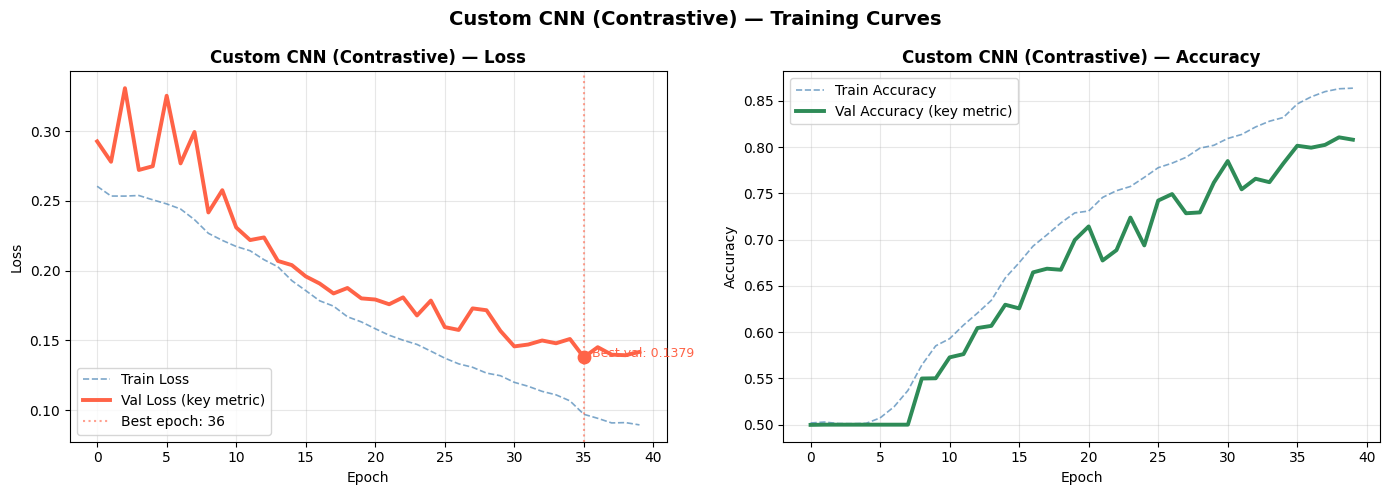

  → Best val_loss : 0.1379  (epoch 36)
  → Final train_loss: 0.0894
  Best val_loss : 0.1379


In [19]:
# 1. Training Custom CNN with Contrastive Loss
print("Training Custom CNN with Contrastive Loss")

custom_backbone_c = build_cnn_backbone()
model_custom_c    = build_siamese_contrastive(custom_backbone_c)
model_custom_c.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss=get_contrastive_loss(margin=CONTRASTIVE_MARGIN),
    metrics=[contrastive_accuracy]
)

history_custom_c = model_custom_c.fit(
    ds_pairs_train,
    validation_data=ds_pairs_val,
    epochs=EPOCHS,
    callbacks=make_callbacks("cnn_contrastive"),
    verbose=1
)

plot_training_history(history_custom_c, "Custom CNN (Contrastive)")
print(f"  Best val_loss : {min(history_custom_c.history['val_loss']):.4f}")


Training Custom CNN with Triplet Loss
Epoch 1/40
116/116 ━━━━━━━━━━━━━━━━━━━━ 90s 446ms/step - loss: 0.4777 - triplet_accuracy: 0.5436 - val_loss: 0.4875 - val_triplet_accuracy: 0.5358 - learning_rate: 0.0010
Epoch 2/40
116/116 ━━━━━━━━━━━━━━━━━━━━ 45s 256ms/step - loss: 0.4636 - triplet_accuracy: 0.5620 - val_loss: 0.4753 - val_triplet_accuracy: 0.5542 - learning_rate: 0.0010
Epoch 3/40
116/116 ━━━━━━━━━━━━━━━━━━━━ 44s 257ms/step - loss: 0.4699 - triplet_accuracy: 0.5508 - val_loss: 0.4856 - val_triplet_accuracy: 0.5312 - learning_rate: 0.0010
Epoch 4/40
116/116 ━━━━━━━━━━━━━━━━━━━━ 45s 257ms/step - loss: 0.4692 - triplet_accuracy: 0.5511 - val_loss: 0.4926 - val_triplet_accuracy: 0.5262 - learning_rate: 0.0010
Epoch 5/40
116/116 ━━━━━━━━━━━━━━━━━━━━ 47s 263ms/step - loss: 0.4651 - triplet_accuracy: 0.5628 - val_loss: 0.4390 - val_triplet_accuracy: 0.5878 - learning_rate: 0.0010
Epoch 6/40
116/116 ━━━━━━━━━━━━━━━━━━━━ 44s 257ms/step - loss: 0.4496 - triplet_accuracy: 0.5850 - val_loss

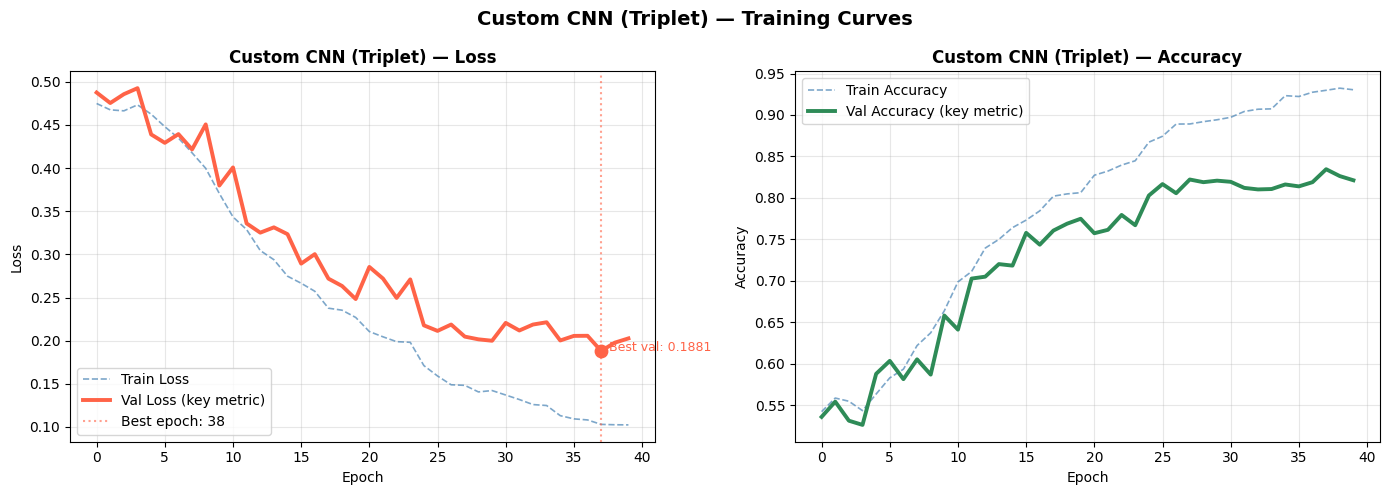

  → Best val_loss : 0.1881  (epoch 38)
  → Final train_loss: 0.1024
  Best val_loss : 0.1881


In [20]:
# 2. Custom CNN + Triplet Loss
print("Training Custom CNN with Triplet Loss")

custom_backbone_t = build_cnn_backbone()
model_custom_t    = build_siamese_triplet(custom_backbone_t)
model_custom_t.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss=get_triplet_loss(margin=TRIPLET_MARGIN),
    metrics=[triplet_accuracy]
)

history_custom_t = model_custom_t.fit(
    ds_triplets_train,
    validation_data=ds_triplets_val,
    epochs=EPOCHS,
    callbacks=make_callbacks("cnn_triplet"),
    verbose=1
)

plot_training_history(history_custom_t, "Custom CNN (Triplet)")
print(f"  Best val_loss : {min(history_custom_t.history['val_loss']):.4f}")

Training EfficientNetB0 with Contrastive Loss (Phase 1: warm-up)
Epoch 1/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 130s 331ms/step - contrastive_accuracy: 0.5520 - loss: 0.2689 - val_contrastive_accuracy: 0.6290 - val_loss: 0.1996 - learning_rate: 3.0000e-04
Epoch 2/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 45s 149ms/step - contrastive_accuracy: 0.6770 - loss: 0.1901 - val_contrastive_accuracy: 0.6866 - val_loss: 0.1791 - learning_rate: 3.0000e-04
Epoch 3/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 46s 155ms/step - contrastive_accuracy: 0.7159 - loss: 0.1705 - val_contrastive_accuracy: 0.7071 - val_loss: 0.1665 - learning_rate: 3.0000e-04
Epoch 4/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 45s 148ms/step - contrastive_accuracy: 0.7376 - loss: 0.1581 - val_contrastive_accuracy: 0.7136 - val_loss: 0.1635 - learning_rate: 3.0000e-04
Epoch 5/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 46s 157ms/step - contrastive_accuracy: 0.7615 - loss: 0.1479 - val_contrastive_accuracy: 0.7267 - val_loss: 0.1593 - learning_rate: 3.0000e-04
Epoch 6/20
232/232 

2026-04-17 14:31:34.974097: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 14:31:35.164580: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 14:31:35.454182: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 14:31:35.673051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 14:31:35.890156: E external/local_xla/xla/stream_

231/232 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - contrastive_accuracy: 0.6465 - loss: 0.2194

2026-04-17 14:32:34.772890: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 14:32:34.961394: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 14:32:35.213607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 14:32:35.428285: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 14:32:35.696916: E external/local_xla/xla/stream_

232/232 ━━━━━━━━━━━━━━━━━━━━ 148s 347ms/step - contrastive_accuracy: 0.6467 - loss: 0.2193 - val_contrastive_accuracy: 0.6800 - val_loss: 0.1931 - learning_rate: 1.0000e-05
Epoch 2/25
232/232 ━━━━━━━━━━━━━━━━━━━━ 44s 149ms/step - contrastive_accuracy: 0.6999 - loss: 0.1852 - val_contrastive_accuracy: 0.7027 - val_loss: 0.1807 - learning_rate: 1.0000e-05
Epoch 3/25
232/232 ━━━━━━━━━━━━━━━━━━━━ 46s 155ms/step - contrastive_accuracy: 0.7290 - loss: 0.1652 - val_contrastive_accuracy: 0.7143 - val_loss: 0.1733 - learning_rate: 1.0000e-05
Epoch 4/25
232/232 ━━━━━━━━━━━━━━━━━━━━ 45s 151ms/step - contrastive_accuracy: 0.7560 - loss: 0.1532 - val_contrastive_accuracy: 0.7255 - val_loss: 0.1681 - learning_rate: 1.0000e-05
Epoch 5/25
232/232 ━━━━━━━━━━━━━━━━━━━━ 44s 150ms/step - contrastive_accuracy: 0.7703 - loss: 0.1450 - val_contrastive_accuracy: 0.7374 - val_loss: 0.1629 - learning_rate: 1.0000e-05
Epoch 6/25
232/232 ━━━━━━━━━━━━━━━━━━━━ 45s 154ms/step - contrastive_accuracy: 0.7722 - loss: 0

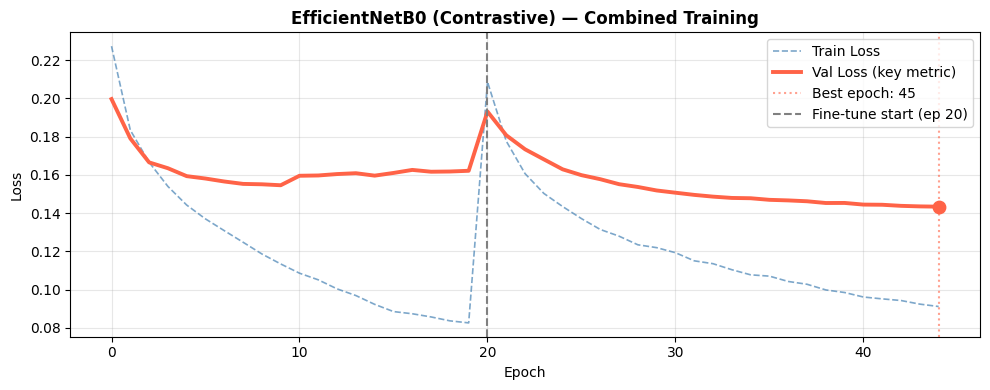

  Best val_loss : 0.1434


In [21]:
# 3. EfficientNetB0 + Contrastive Loss (2-phase)
print("Training EfficientNetB0 with Contrastive Loss (Phase 1: warm-up)")

efficientnet_backbone_c, base_c = build_efficientnet_backbone()
model_efficientnet_c = build_siamese_contrastive(efficientnet_backbone_c)
model_efficientnet_c.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),   # slightly lower than CNN — head-only warm-up
    loss=get_contrastive_loss(margin=CONTRASTIVE_MARGIN),
    metrics=[contrastive_accuracy]
)

# Phase 1: Frozen base —> train embedding head only (15 epochs)
history_eff_c_p1 = model_efficientnet_c.fit(
    ds_pairs_train,
    validation_data=ds_pairs_val,
    epochs=20,   # 15 -> 20 
    callbacks=make_callbacks("efficientnet_contrastive_p1"),
    verbose=1
)

# Phase 2: Unfreeze top 50 layers of EfficientNetB0 for domain adaptation
print("\n Phase 2: Fine-tuning top EfficientNetB0 layers")
base_c.trainable = True
for layer in base_c.layers[:-50]:
    layer.trainable = False

# Recompile at very low LR to avoid destroying pretrained weights
model_efficientnet_c.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=get_contrastive_loss(margin=CONTRASTIVE_MARGIN),
    metrics=[contrastive_accuracy]
)

history_eff_c_p2 = model_efficientnet_c.fit(
    ds_pairs_train,
    validation_data=ds_pairs_val,
    epochs=25,
    callbacks=make_callbacks("efficientnet_contrastive"),
    verbose=1
)

# Combined history plot
combined_loss_eff_c = history_eff_c_p1.history["loss"]    + history_eff_c_p2.history["loss"]
combined_val_eff_c  = history_eff_c_p1.history["val_loss"] + history_eff_c_p2.history["val_loss"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(combined_loss_eff_c, label="Train Loss",             color="steelblue", linewidth=1.2, linestyle="--", alpha=0.7)
ax.plot(combined_val_eff_c,  label="Val Loss (key metric)",  color="tomato",    linewidth=2.8)
best_ep = int(np.argmin(combined_val_eff_c))
ax.axvline(best_ep, color="tomato",  linestyle=":", alpha=0.6, label=f"Best epoch: {best_ep+1}")
ax.scatter(best_ep, combined_val_eff_c[best_ep], color="tomato", s=80, zorder=5)
ax.axvline(20,      color="grey",    linestyle="--",            label="Fine-tune start (ep 20)")
ax.set_title("EfficientNetB0 (Contrastive) — Combined Training", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"  Best val_loss : {min(combined_val_eff_c):.4f}")

Training EfficientNetB0 with Triplet Loss (Phase 1: warm-up)
Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 157s 734ms/step - loss: 0.3457 - triplet_accuracy: 0.7401 - val_loss: 0.2362 - val_triplet_accuracy: 0.8006 - learning_rate: 3.0000e-04
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 34s 168ms/step - loss: 0.2354 - triplet_accuracy: 0.8210 - val_loss: 0.2118 - val_triplet_accuracy: 0.8300 - learning_rate: 3.0000e-04
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 33s 168ms/step - loss: 0.2077 - triplet_accuracy: 0.8423 - val_loss: 0.2018 - val_triplet_accuracy: 0.8396 - learning_rate: 3.0000e-04
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 32s 161ms/step - loss: 0.1776 - triplet_accuracy: 0.8657 - val_loss: 0.2024 - val_triplet_accuracy: 0.8410 - learning_rate: 3.0000e-04
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 32s 172ms/step - loss: 0.1642 - triplet_accuracy: 0.8814 - val_loss: 0.1995 - val_triplet_accuracy: 0.8281 - learning_rate: 3.0000e-04
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 31s 164ms/step - loss: 

2026-04-17 15:06:12.253874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 15:06:12.446069: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 15:06:12.733627: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 15:06:12.949020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 15:06:13.291546: E external/local_xla/xla/stream_

116/116 ━━━━━━━━━━━━━━━━━━━━ 172s 771ms/step - loss: 0.3132 - triplet_accuracy: 0.7424 - val_loss: 0.2762 - val_triplet_accuracy: 0.7610 - learning_rate: 1.0000e-05
Epoch 2/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 35s 183ms/step - loss: 0.2578 - triplet_accuracy: 0.8021 - val_loss: 0.2486 - val_triplet_accuracy: 0.7900 - learning_rate: 1.0000e-05
Epoch 3/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 35s 183ms/step - loss: 0.2164 - triplet_accuracy: 0.8361 - val_loss: 0.2290 - val_triplet_accuracy: 0.8097 - learning_rate: 1.0000e-05
Epoch 4/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 36s 190ms/step - loss: 0.1901 - triplet_accuracy: 0.8609 - val_loss: 0.2162 - val_triplet_accuracy: 0.8176 - learning_rate: 1.0000e-05
Epoch 5/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 34s 184ms/step - loss: 0.1790 - triplet_accuracy: 0.8729 - val_loss: 0.2072 - val_triplet_accuracy: 0.8231 - learning_rate: 1.0000e-05
Epoch 6/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 34s 187ms/step - loss: 0.1553 - triplet_accuracy: 0.8930 - val_loss: 0.1993 - val_triplet_accur

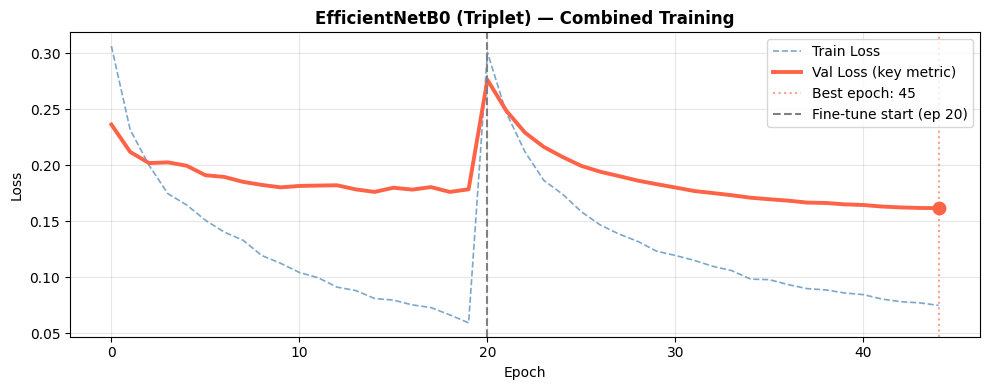

  Best val_loss : 0.1616


In [22]:
#  4. EfficientNetB0 + Triplet Loss (2-phase) 
print("Training EfficientNetB0 with Triplet Loss (Phase 1: warm-up)")

efficientnet_backbone_t, base_t = build_efficientnet_backbone()
model_efficientnet_t = build_siamese_triplet(efficientnet_backbone_t)
model_efficientnet_t.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=get_triplet_loss(margin=TRIPLET_MARGIN),
    metrics=[triplet_accuracy]
)

history_eff_t_p1 = model_efficientnet_t.fit(
    ds_triplets_train,
    validation_data=ds_triplets_val,
    epochs=20,
    callbacks=make_callbacks("efficientnet_triplet_p1"),
    verbose=1
)

print("\n Phase 2: Fine-tuning top EfficientNetB0 layers")
base_t.trainable = True
for layer in base_t.layers[:-50]:
    layer.trainable = False

model_efficientnet_t.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=get_triplet_loss(margin=TRIPLET_MARGIN),
    metrics=[triplet_accuracy]
)

history_eff_t_p2 = model_efficientnet_t.fit(
    ds_triplets_train,
    validation_data=ds_triplets_val,
    epochs=25,
    callbacks=make_callbacks("efficientnet_triplet"),
    verbose=1
)

combined_loss_eff_t = history_eff_t_p1.history["loss"]    + history_eff_t_p2.history["loss"]
combined_val_eff_t  = history_eff_t_p1.history["val_loss"] + history_eff_t_p2.history["val_loss"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(combined_loss_eff_t, label="Train Loss",            color="steelblue", linewidth=1.2, linestyle="--", alpha=0.7)
ax.plot(combined_val_eff_t,  label="Val Loss (key metric)", color="tomato",    linewidth=2.8)
best_ep = int(np.argmin(combined_val_eff_t))
ax.axvline(best_ep, color="tomato", linestyle=":", alpha=0.6, label=f"Best epoch: {best_ep+1}")
ax.scatter(best_ep, combined_val_eff_t[best_ep], color="tomato", s=80, zorder=5)
ax.axvline(20,      color="grey",   linestyle="--",            label="Fine-tune start (ep 20)")
ax.set_title("EfficientNetB0 (Triplet) — Combined Training", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"  Best val_loss : {min(combined_val_eff_t):.4f}")

### SECTION 8: Evaluation & Visualization
Evaluating all final models on the entirely unseen TEST dataset.
Distance Distribution Plots show how well the embedding space separates same vs different persons.

In [36]:
print("-> Final Evaluation on Unseen TEST Dataset <-")

print("\n1. Custom CNN (Contrastive):")
model_custom_c.evaluate(ds_pairs_test)

print("\n2. Custom CNN (Triplet):")
model_custom_t.evaluate(ds_triplets_test)

print("\n3. EfficientNetB0 (Contrastive):")
model_efficientnet_c.evaluate(ds_pairs_test)

print("\n4. EfficientNetB0 (Triplet):")
model_efficientnet_t.evaluate(ds_triplets_test)

-> Final Evaluation on Unseen TEST Dataset <-

1. Custom CNN (Contrastive):
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - contrastive_accuracy: 0.7877 - loss: 0.1491

2. Custom CNN (Triplet):
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 0.1744 - triplet_accuracy: 0.8705

3. EfficientNetB0 (Contrastive):
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - contrastive_accuracy: 0.8043 - loss: 0.1355

4. EfficientNetB0 (Triplet):
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.1588 - triplet_accuracy: 0.8897


[0.16308078169822693, 0.8847221732139587]

Extracting distances on TEST set...
  Processing Custom CNN (Contrastive)...
  Processing Custom CNN (Triplet)...
  Processing EfficientNetB0 (Contrastive)...
  Processing EfficientNetB0 (Triplet)...


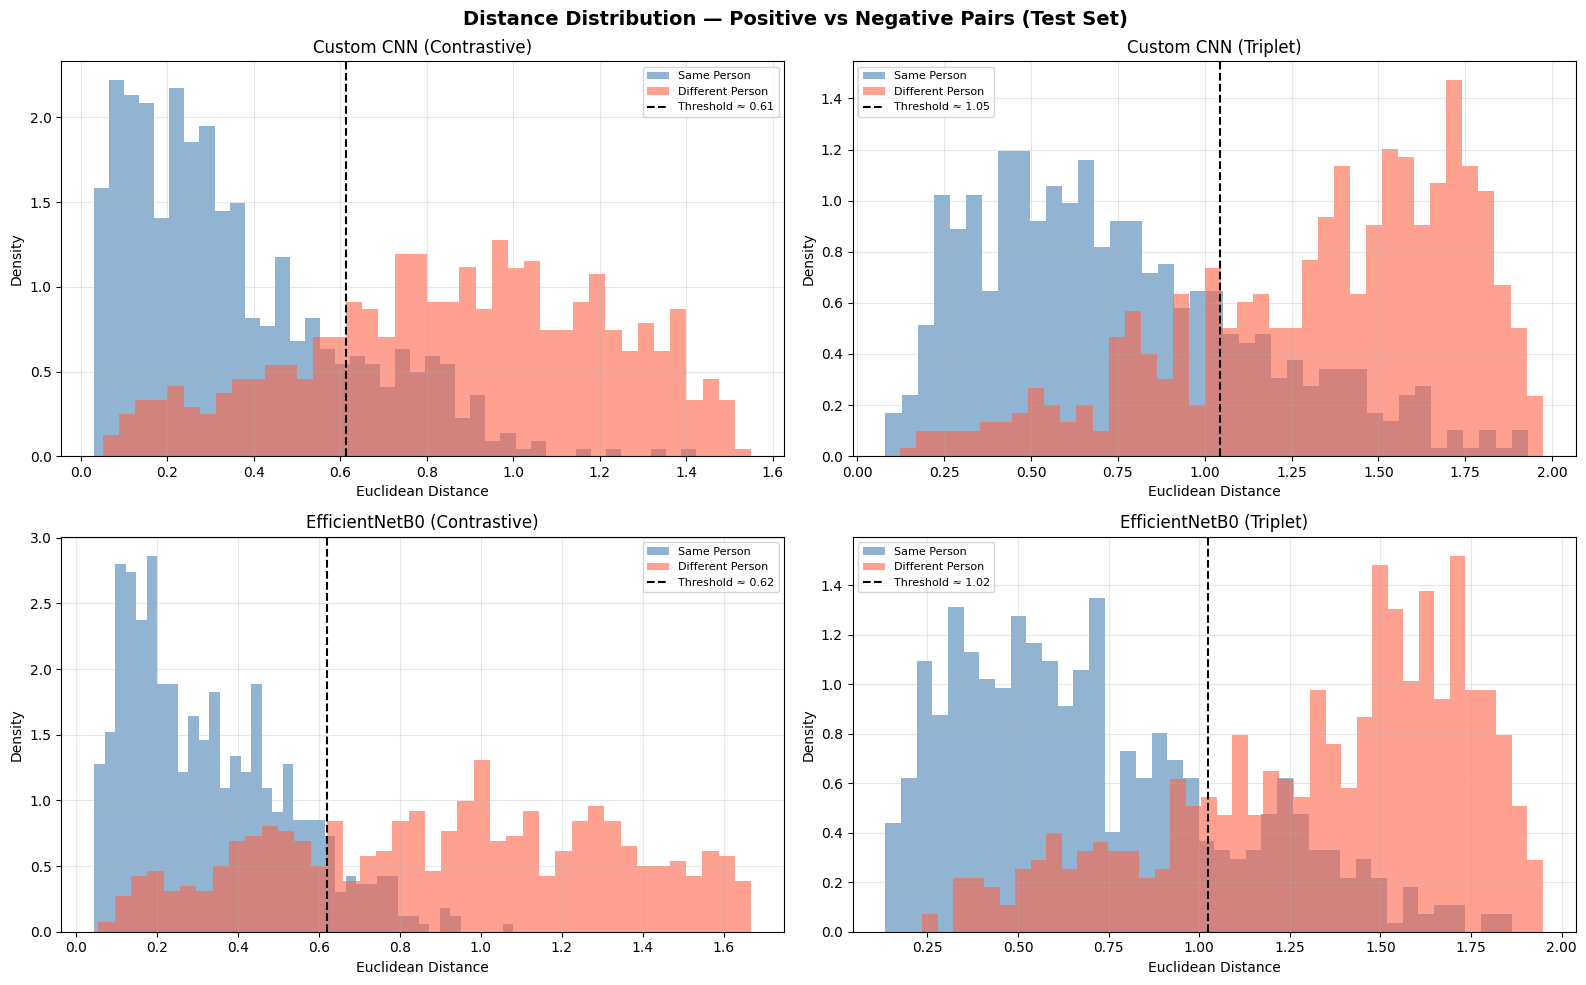

In [24]:
def extract_distances(backbone, dataset, num_batches=20):
    pos_dists, neg_dists = [], []
    for (img_a, img_b), labels in dataset.take(num_batches):
        emb_a = backbone.predict(img_a, verbose=0)
        emb_b = backbone.predict(img_b, verbose=0)
        distances = np.linalg.norm(emb_a - emb_b, axis=1)
        for dist, lbl in zip(distances, labels.numpy()):
            (pos_dists if lbl == 1.0 else neg_dists).append(dist)
    return pos_dists, neg_dists

print("Extracting distances on TEST set...")
models_to_plot = [
    (custom_backbone_c, "Custom CNN (Contrastive)"),
    (custom_backbone_t, "Custom CNN (Triplet)"),
    (efficientnet_backbone_c, "EfficientNetB0 (Contrastive)"),
    (efficientnet_backbone_t, "EfficientNetB0 (Triplet)"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Distance Distribution — Positive vs Negative Pairs (Test Set)",fontsize=14, fontweight="bold")

for ax, (backbone, title) in zip(axes.flatten(), models_to_plot):
    print(f"  Processing {title}...")
    pos_dists, neg_dists = extract_distances(backbone, ds_pairs_test, num_batches=20)

    ax.hist(pos_dists, bins=40, alpha=0.6, label="Same Person",      color="steelblue",  density=True)
    ax.hist(neg_dists, bins=40, alpha=0.6, label="Different Person", color="tomato",     density=True)

    # Dynamic threshold = midpoint of means
    if pos_dists and neg_dists:
        thresh = (np.mean(pos_dists) + np.mean(neg_dists)) / 2
        ax.axvline(thresh, color="black", linestyle="--",
                    label=f"Threshold ≈ {thresh:.2f}")

    ax.set_title(title)
    ax.set_xlabel("Euclidean Distance")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("distance_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### SECTION 9: Inference Pipeline
A function that takes two **unseen** image paths and outputs:
- The Euclidean distance between embeddings
- The similarity decision (SAME / DIFFERENT)
- A visual display of the pair with the decision overlay

Testing SAME person pair:


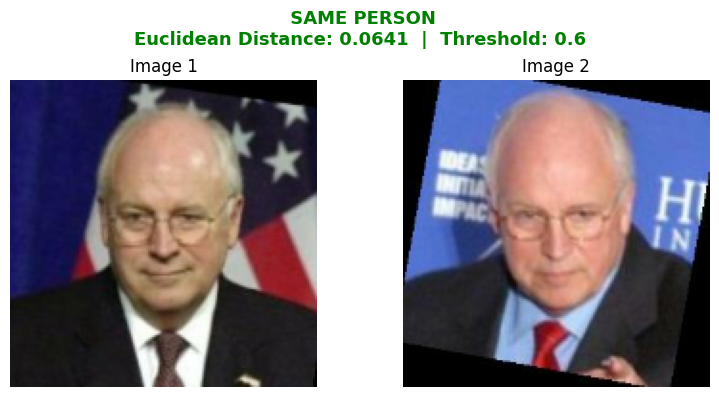

{'distance': 0.0641, 'decision': ' SAME PERSON'}

Testing DIFFERENT persons pair:


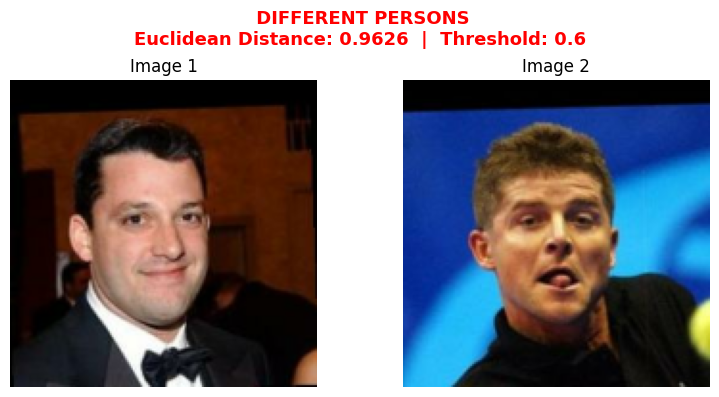

{'distance': 0.9626, 'decision': ' DIFFERENT PERSONS'}

Same pair — EfficientNetB0 backbone:


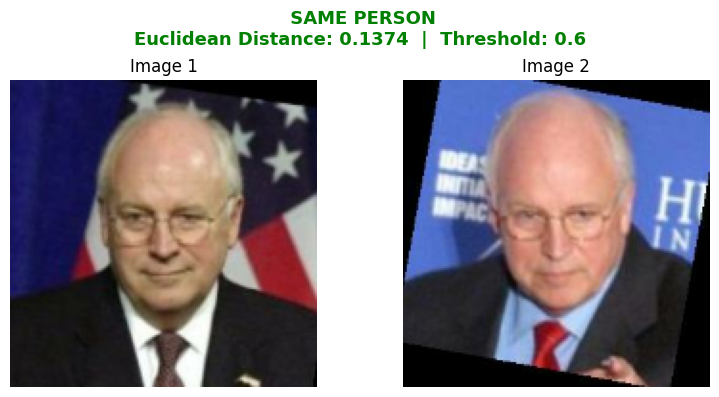

{'distance': 0.1374, 'decision': ' SAME PERSON'}

In [28]:
def verify_faces(img_path1, img_path2, backbone, threshold=0.6):

    img1 = load_image(img_path1)
    img2 = load_image(img_path2)

    emb1 = backbone.predict(tf.expand_dims(img1, 0), verbose=0)
    emb2 = backbone.predict(tf.expand_dims(img2, 0), verbose=0)

    distance = float(np.linalg.norm(emb1 - emb2))
    is_same  = distance < threshold
    decision = " SAME PERSON" if is_same else " DIFFERENT PERSONS"
    color    = "green" if is_same else "red"

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img1.numpy()); axes[0].set_title("Image 1"); axes[0].axis("off")
    axes[1].imshow(img2.numpy()); axes[1].set_title("Image 2"); axes[1].axis("off")

    plt.suptitle(f"{decision}\nEuclidean Distance: {distance:.4f}  |  Threshold: {threshold}",
                 color=color, fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()

    return {"distance": round(distance, 4), "decision": decision}


# Demo: Test positive pair (same person) 
sample_pos = df_pairs_test[df_pairs_test["label"] == 1].iloc[400]
print("Testing SAME person pair:")
result = verify_faces(sample_pos["path1"], sample_pos["path2"], custom_backbone_c)
print(result)

#  Demo: Test negative pair (different persons) 
sample_neg = df_pairs_test[df_pairs_test["label"] == 0].iloc[700]
print("\nTesting DIFFERENT persons pair:")
result = verify_faces(sample_neg["path1"], sample_neg["path2"], custom_backbone_c)
print(result)

#  Demo: Also test with EfficientNetB0 backbone
print("\nSame pair — EfficientNetB0 backbone:")
verify_faces(sample_pos["path1"], sample_pos["path2"], efficientnet_backbone_c)

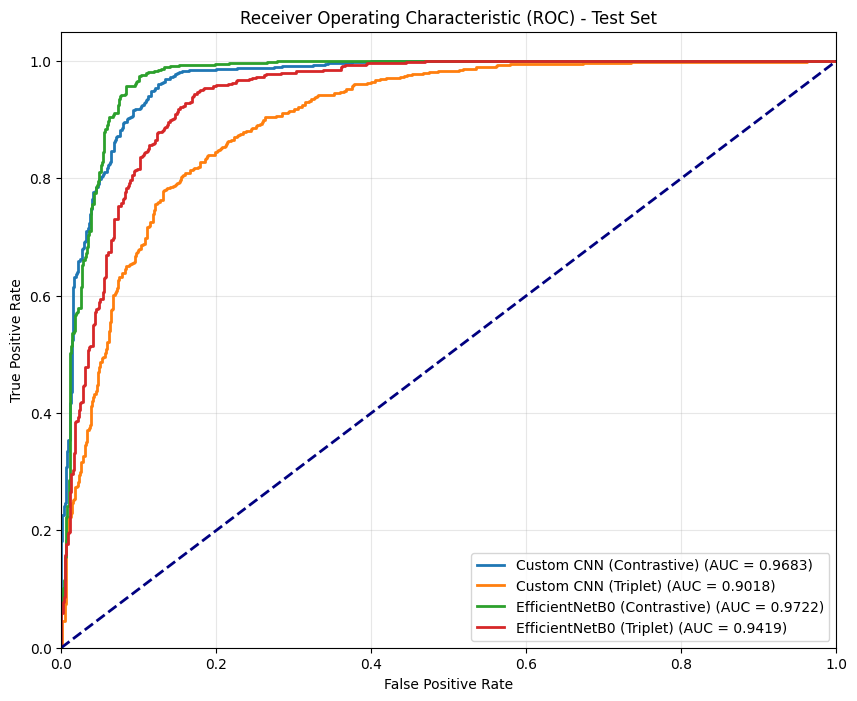

In [39]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(models_list, dataset, num_batches=20):
    plt.figure(figsize=(10, 8))
    
    for backbone, title in models_list:
        y_true = []
        y_scores = [] # Distances act as inverse similarity scores
        
        for (img_a, img_b), labels in dataset.take(num_batches):
            emb_a = backbone.predict(img_a, verbose=0)
            emb_b = backbone.predict(img_b, verbose=0)
            distances = np.linalg.norm(emb_a - emb_b, axis=1)
            
            y_true.extend(labels.numpy())
            y_scores.extend(distances)

        # In ROC, a 'high' score usually means 'positive class'.
        # Since low distance = Same Person (1), we use negative distance as the score.
        fpr, tpr, _ = roc_curve(y_true, -np.array(y_scores))
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, lw=2, label=f'{title} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) - Test Set')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Execute ROC evaluation
models_to_evaluate = [
    (custom_backbone_c, "Custom CNN (Contrastive)"),
    (custom_backbone_t, "Custom CNN (Triplet)"),
    (efficientnet_backbone_c, "EfficientNetB0 (Contrastive)"),
    (efficientnet_backbone_t, "EfficientNetB0 (Triplet)")
]

plot_roc_curves(models_to_evaluate, ds_pairs_train)

Running Verification with EfficientNetB0 Triplet Backbone


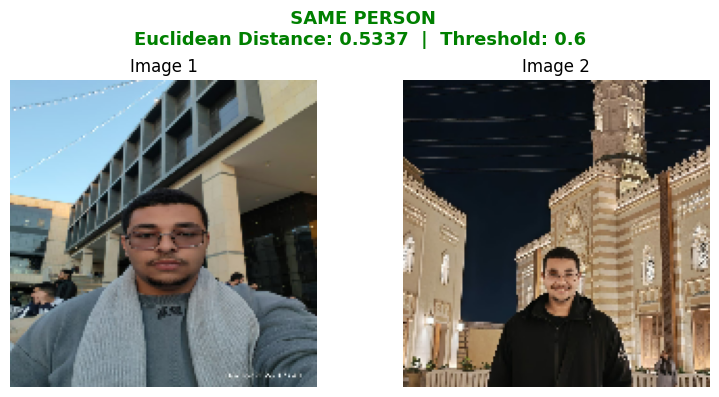


Final Decision:  SAME PERSON
Distance: 0.5337 



In [44]:
my_img1 = "/kaggle/input/datasets/mohamedalisadek/img-test/img1.jpg"
my_img2 = "/kaggle/input/datasets/mohamedalisadek/img-test/img2.jpg"

print("Running Verification with EfficientNetB0 Triplet Backbone")
result = verify_faces(my_img1, my_img2, efficientnet_backbone_t, threshold=0.6)
print(f"\nFinal Decision: {result['decision']}")
print(f"Distance: {result['distance']:.4f} \n")

Running Verification with EfficientNetB0 Triplet Backbone


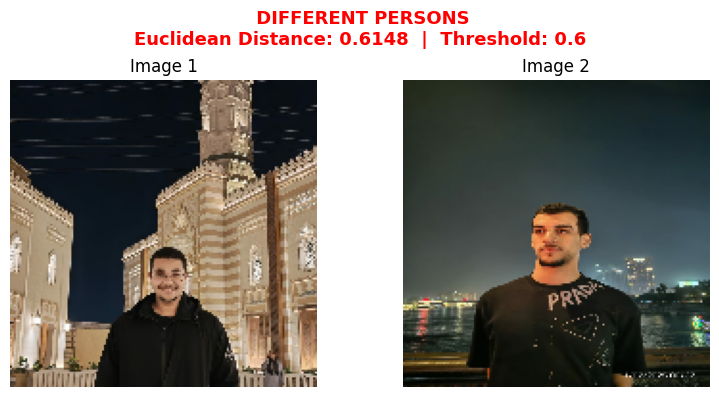


Final Decision:  DIFFERENT PERSONS
Distance: 0.6148 



In [43]:
my_img1 = "/kaggle/input/datasets/mohamedalisadek/img-test/img2.jpg"
my_img2 = "/kaggle/input/datasets/mohamedalisadek/img-test/img3.jpg"

print("Running Verification with EfficientNetB0 Triplet Backbone")
result = verify_faces(my_img1, my_img2, efficientnet_backbone_t, threshold=0.6)
print(f"\nFinal Decision: {result['decision']}")
print(f"Distance: {result['distance']:.4f} \n")